In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import time
import matplotlib
import sys
import pandas as pd

sys.path.append('../')
from carpet_reconstruction import GetCarpetSignal, VEM, get_rho, NKG, num_sort, get_xy, get_angles, inout_mean_checker
from matplotlib.backends.backend_pdf import PdfPages

from lmfit import Model, Parameters

In [2]:
plt.rcParams['figure.dpi'] = 200

In [3]:
gmodel = Model(NKG)
gmodel.set_param_hint('s', min=0.4, max=1.8)
gmodel.set_param_hint('Ne', min=10, max=1e8)

In [4]:
print(gmodel.param_names, gmodel.independent_vars)

['s', 'Ne'] ['x']


In [5]:
path = '../Data/photon_data/'

filenames = [path + filename for filename in os.listdir(path)]
filenames.sort(key=num_sort)

In [7]:
all_data = pd.read_csv('../photon_28k_noroof.csv')

In [8]:
Ne_true = np.array(all_data['Ne'], dtype=int)

(array([2808., 2820., 2934., 2868., 2786., 2799., 2805., 2732., 2873.,
        2775.]),
 array([-1.7998680e+02, -1.4398826e+02, -1.0798972e+02, -7.1991180e+01,
        -3.5992640e+01,  5.9000000e-03,  3.6004440e+01,  7.2002980e+01,
         1.0800152e+02,  1.4400006e+02,  1.7999860e+02]),
 <BarContainer object of 10 artists>)

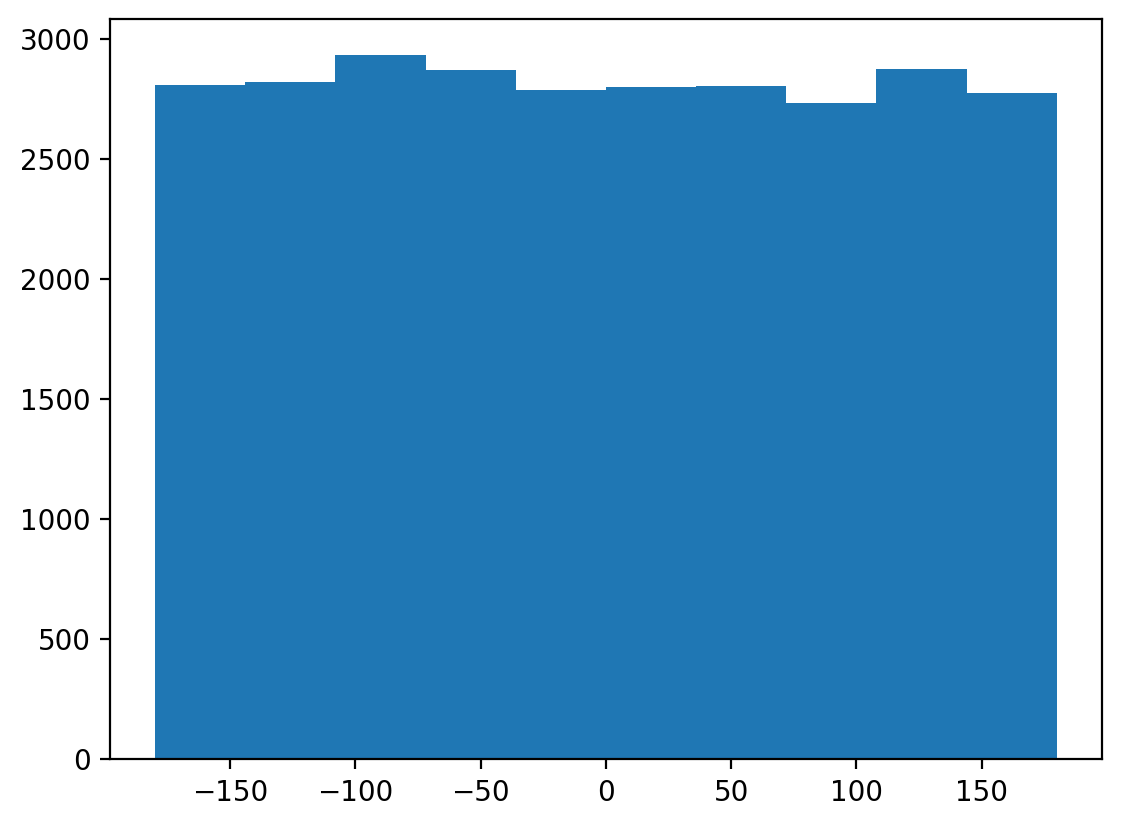

In [33]:
plt.hist(all_data['Phi, deg'])

In [9]:
E_arr = []
theta_true_arr = []
theta_rec_arr = []
phi_true_arr = []
phi_rec_arr = []
Ne_true_arr = []
Ne_rec_arr = []
Ne_err_arr = []
N_mu = []
s_rec_arr = []
s_err_arr = []
x_rec_arr = []
y_rec_arr = []
Chi_sq_arr = []
E_trig = []

for filename in filenames:

    print(filename)
    
    file = uproot.open(filename)
    
    names = np.array(file.keys())
    times = names[:len(names) // 3]
    cover_hists = names[len(names) // 3::2]
    muon_hists = names[len(names) // 3 + 1::2]

    cover_signals = np.zeros((len(cover_hists), 20, 20))
    
    for i, hist in enumerate(cover_hists):
        cov_hist = np.copy(np.flip(file[hist].values().T, 0))
        cover_signals[i] = VEM(GetCarpetSignal(cov_hist))

    muon_summ = np.zeros(len(muon_hists))

    for i, muon_hist in enumerate(muon_hists):
        muon_summ[i] = file[muon_hist].values().sum()
        
    time_array = np.zeros((len(times), 4))
    
    for i, t in enumerate(times):
        time_array[i] = file[t]['t_ns'].array(library='np')[1:5]

    for i in range(len(cover_signals)):
    
        sig = cover_signals[i]
        times = time_array[i]

        if (np.all(times) and (np.sum(sig) > 15)):
            
            E_trig.append(float(cover_hists[i].split('_')[0]))
        
        if (inout_mean_checker(sig) and (np.all(times)) and (np.count_nonzero(sig) > 50)):

            x_rec, y_rec = get_xy(sig)
            theta_rec, phi_rec = get_angles(times)

            if (np.abs(x_rec) < 12.6) and (np.abs(y_rec) < 12.6) and (theta_rec < np.radians(40)):

                E_true = float(cover_hists[i].split('_')[0])
                theta_true = float(cover_hists[i].split('_')[1])
                phi_true = float(cover_hists[i].split('_')[2])
            
                r, rho = get_rho(sig, angles=np.array([phi_rec, theta_rec]))
            
                result = gmodel.fit(rho, x=r)
            
                Ne_rec = result.params['Ne'].value
                Ne_err = result.params['Ne'].stderr
                s_rec = result.params['s'].value
                s_err = result.params['s'].stderr
                Chi_sq = result.chisqr

                E_arr.append(E_true)
                theta_true_arr.append(theta_true)
                theta_rec_arr.append(np.degrees(theta_rec))
                phi_true_arr.append(phi_true)
                phi_rec_arr.append(np.degrees(phi_rec))
                Ne_true_arr.append(Ne_true[i])
                Ne_rec_arr.append(Ne_rec)
                Ne_err_arr.append(Ne_err)
                N_mu.append(muon_summ[i])
                s_rec_arr.append(s_rec)
                s_err_arr.append(s_err)
                x_rec_arr.append(x_rec)
                y_rec_arr.append(y_rec)
                Chi_sq_arr.append(Chi_sq)

print('fin')

../Data/photon_data/output0.root
../Data/photon_data/output1.root
../Data/photon_data/output2.root
../Data/photon_data/output3.root


C:\Users\taunt\GitProjects\Carpet-3-Model\NKG_fit\..\carpet_reconstruction.py:297: RuntimeWarning: invalid value encountered in sqrt
  nz : float = np.sqrt(1-nx**2-ny**2) # Иногда 1-nx**2-ny**2 оказывается меньше 0, что означает что в данном случае приближение плоского фронта не работает


../Data/photon_data/output4.root
../Data/photon_data/output5.root
../Data/photon_data/output6.root
../Data/photon_data/output7.root
../Data/photon_data/output8.root
../Data/photon_data/output9.root
../Data/photon_data/output10.root
../Data/photon_data/output11.root
../Data/photon_data/output12.root
../Data/photon_data/output13.root
../Data/photon_data/output14.root
../Data/photon_data/output15.root
../Data/photon_data/output16.root
../Data/photon_data/output17.root
../Data/photon_data/output18.root
../Data/photon_data/output19.root
../Data/photon_data/output20.root
../Data/photon_data/output21.root
../Data/photon_data/output22.root
../Data/photon_data/output23.root
../Data/photon_data/output24.root
../Data/photon_data/output25.root
../Data/photon_data/output26.root
../Data/photon_data/output27.root
../Data/photon_data/output28.root
fin


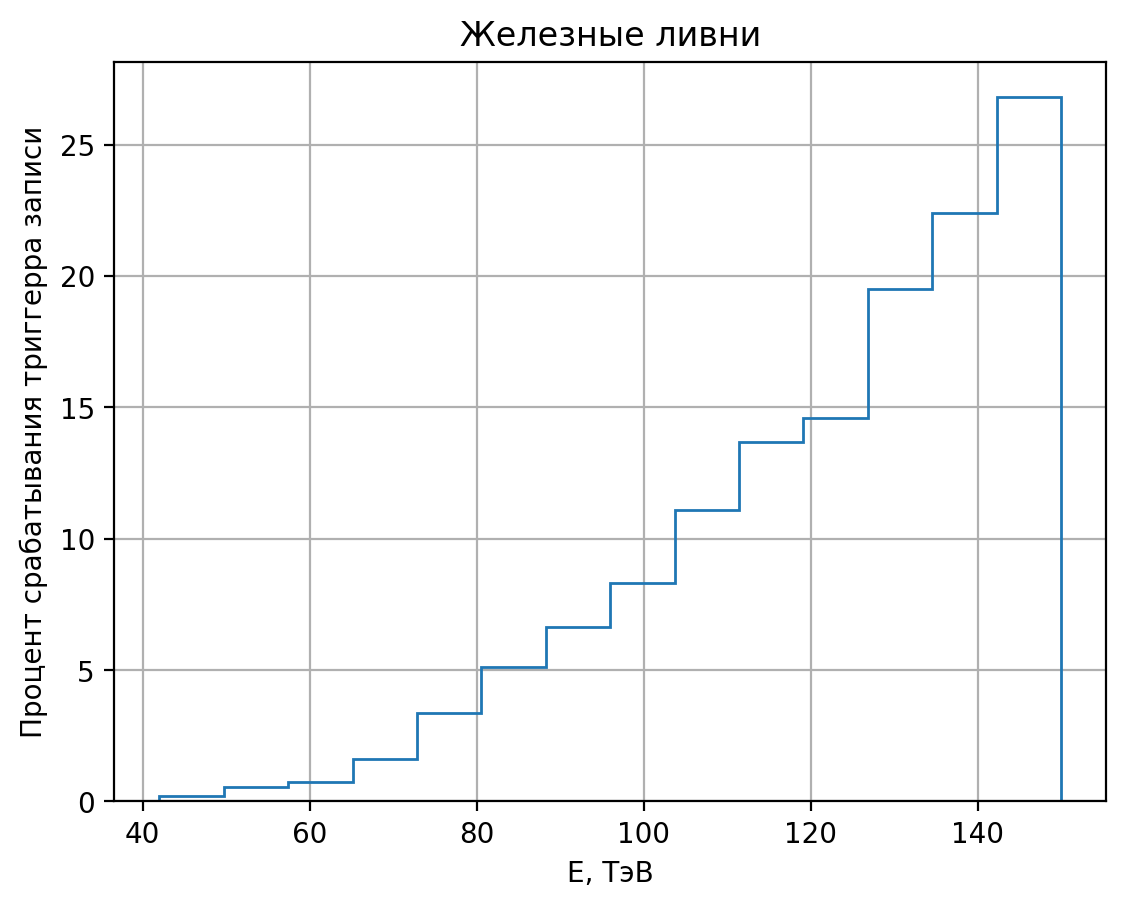

In [60]:
plt.hist(E_trig, histtype='step', bins=14, weights = np.hstack((np.ones(len(E_trig)-1)/20, 1/22)))

plt.xlabel('E, ТэВ')
plt.ylabel('Процент срабатывания триггерра записи')

plt.title('Железные ливни')

plt.grid()

plt.savefig('iron_record_trigger.png')

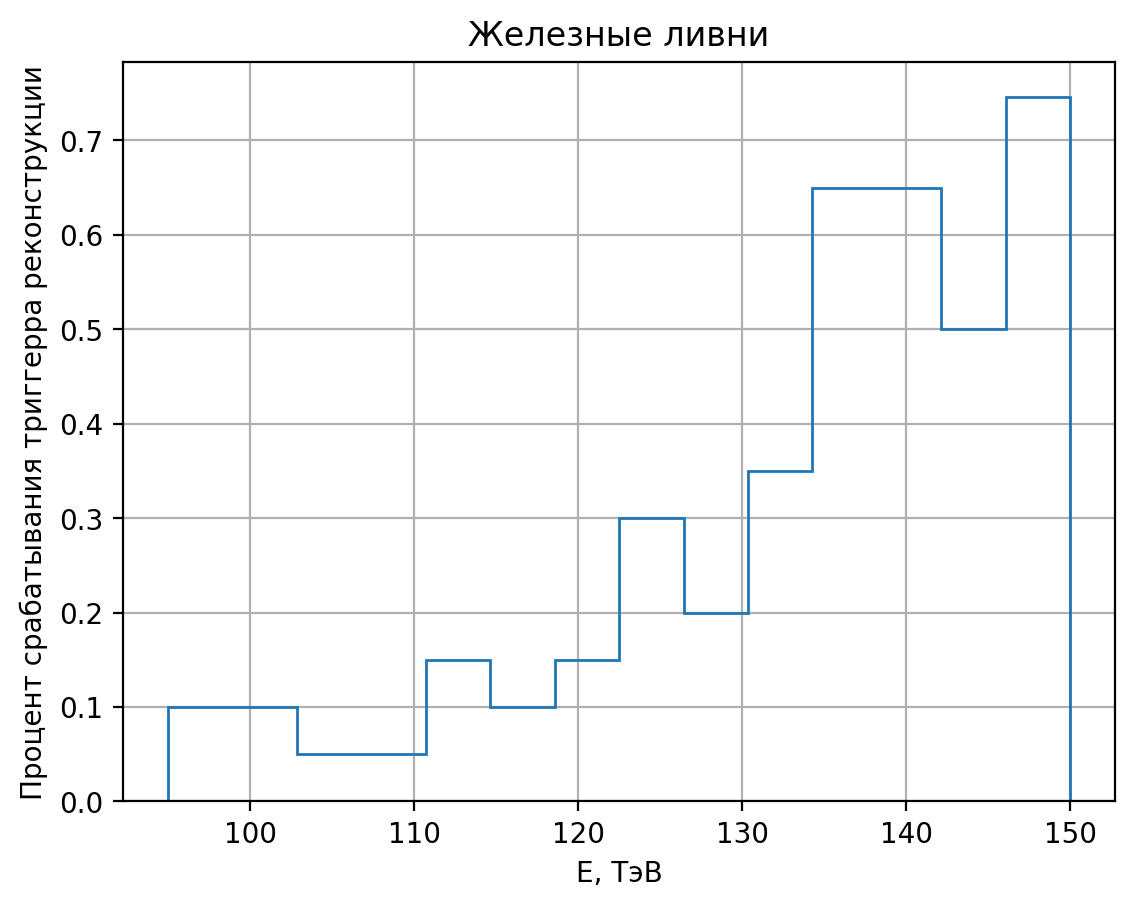

In [59]:
plt.hist(E_arr, histtype='step', bins=14, weights = np.hstack((np.ones(len(E_arr)-1)/20, 1/22)))

plt.xlabel('E, ТэВ')
plt.ylabel('Процент срабатывания триггерра реконструкции')

plt.title('Железные ливни')

plt.grid()

plt.savefig('iron_reconstruction_trigger.png')

In [10]:
d = {'E': E_arr, 'theta_true': theta_true_arr, 'theta_rec': theta_rec_arr, 'phi_true': phi_true_arr, 'phi_rec': phi_rec_arr, 'Ne_true': Ne_true_arr, 
     'Ne_rec': Ne_rec_arr, 'Ne_err': Ne_err_arr, 'N_mu': N_mu, 's_rec': s_rec_arr, 's_err': s_err_arr, 'x_rec': x_rec_arr, 'y_rec': y_rec_arr, 'Chi_sq': Chi_sq_arr}
ReconstructionData = pd.DataFrame(d)
ReconstructionData

,E,theta_true,theta_rec,phi_true,phi_rec,Ne_true,Ne_rec,Ne_err,N_mu,s_rec,s_err,x_rec,y_rec,Chi_sq
0,13.0,19.44990,24.191334,-170.97600,147.657591,46623,15221.261620,2023.420822,0.0,0.911731,0.025586,-0.589671,-3.626048,3.235742e+04
1,13.0,15.99100,21.592615,55.40430,337.996015,47940,207578.812836,49186.599046,0.0,1.541773,0.040322,2.504577,1.723134,5.088122e+04
2,13.0,7.09744,22.598383,-72.57880,124.983442,78562,34770.044039,16645.636019,0.0,1.041088,0.265570,-0.942936,0.180832,7.385683e+04
3,14.0,15.04460,15.022520,179.35300,229.142324,58230,42184.193801,19284.666700,0.0,1.156011,0.202847,-0.402828,-2.590924,4.940771e+04
4,14.0,5.83809,10.228790,175.95000,155.928513,107570,131143.221178,9335.895536,0.0,1.104373,0.008820,0.235045,-1.057570,1.290369e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6749,150.0,27.37450,27.537389,-137.96500,207.682382,5014,418070.689824,179990.539040,0.0,1.800000,0.001088,-3.857790,-4.242842,3.601024e+03
6750,150.0,16.04460,12.968412,-5.11778,50.930640,751,133596.552041,4431.513749,0.0,1.320694,0.001426,-0.305974,2.575167,2.188768e+05
6751,150.0,18.45820,24.565611,-79.44380,269.745114,1651,99366.833428,31512.350784,0.0,1.245019,0.209220,-3.257253,0.437433,1.405953e+05
6752,150.0,12.29430,37.296182,65.39890,88.723679,5307,120556.046105,13272.768851,0.0,1.435285,0.023886,1.814003,1.195979,5.453740e+04


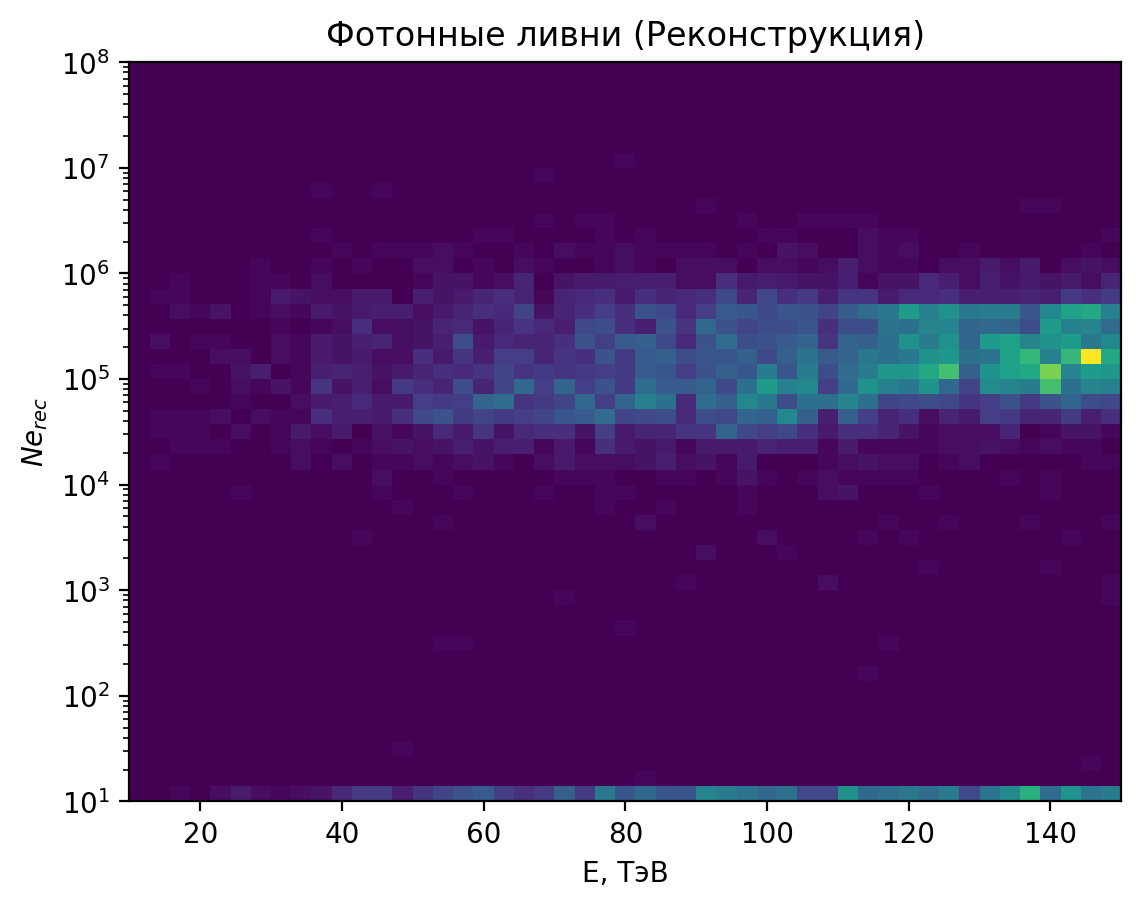

In [47]:
xbins = np.linspace(10, 150, 50)
ybins = 10**np.linspace(1, 8, 50)

plt.hist2d(ReconstructionData['E'], ReconstructionData['Ne_rec'], bins=(xbins, ybins))
# plt.scatter(ReconstructionData['E'], ReconstructionData['Ne_rec'], s=0.1)

plt.yscale('log')

plt.xlabel('E, ТэВ')
plt.ylabel('$Ne_{rec}$')

plt.title('Фотонные ливни (Реконструкция)')

plt.savefig('photon_ne_rec.png')

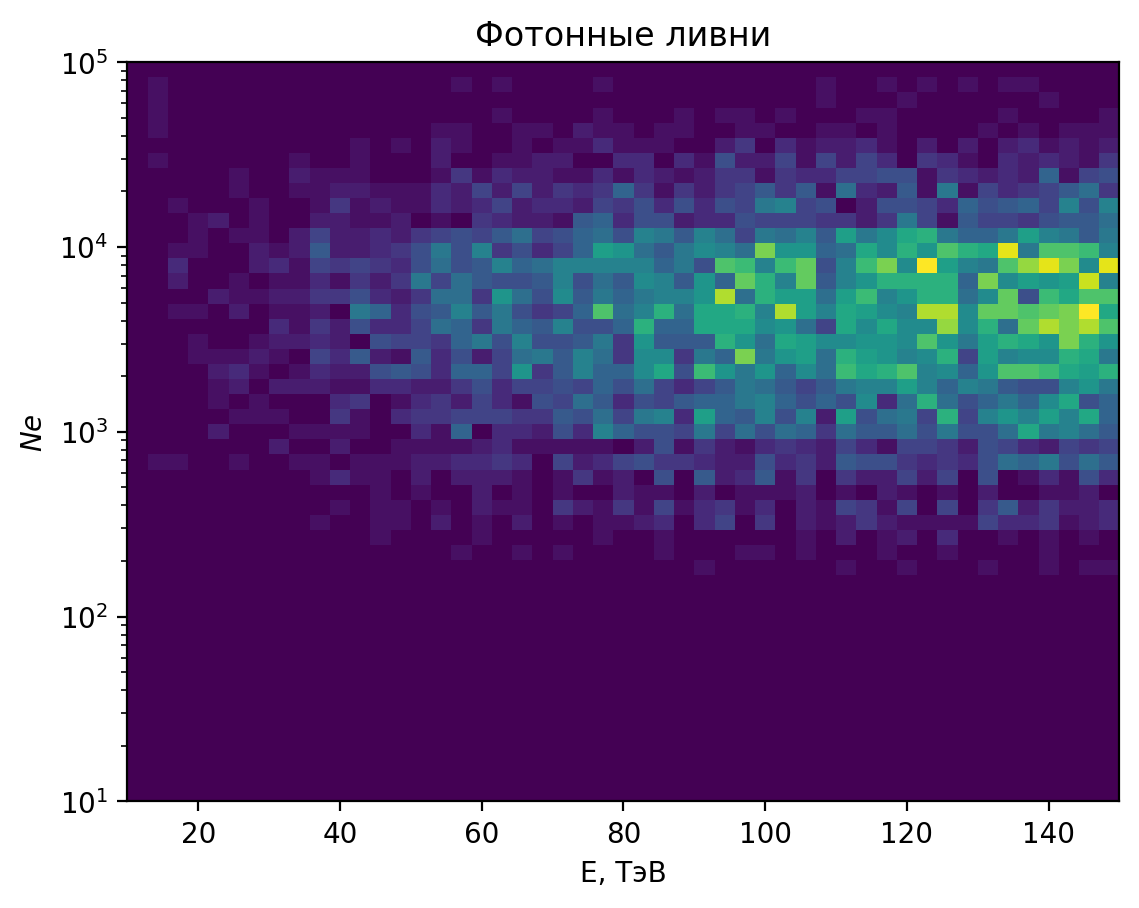

In [46]:
xbins = np.linspace(10, 150, 50)
ybins = 10**np.linspace(1, 5, 50)

plt.hist2d(ReconstructionData['E'], ReconstructionData['Ne_true'], bins=(xbins, ybins))

plt.yscale('log')

plt.xlabel('E, ТэВ')
plt.ylabel('$Ne$')

plt.title('Фотонные ливни')

plt.savefig('photon_ne_true.png')

Text(0.5, 1.0, 'Фотонные ливни')

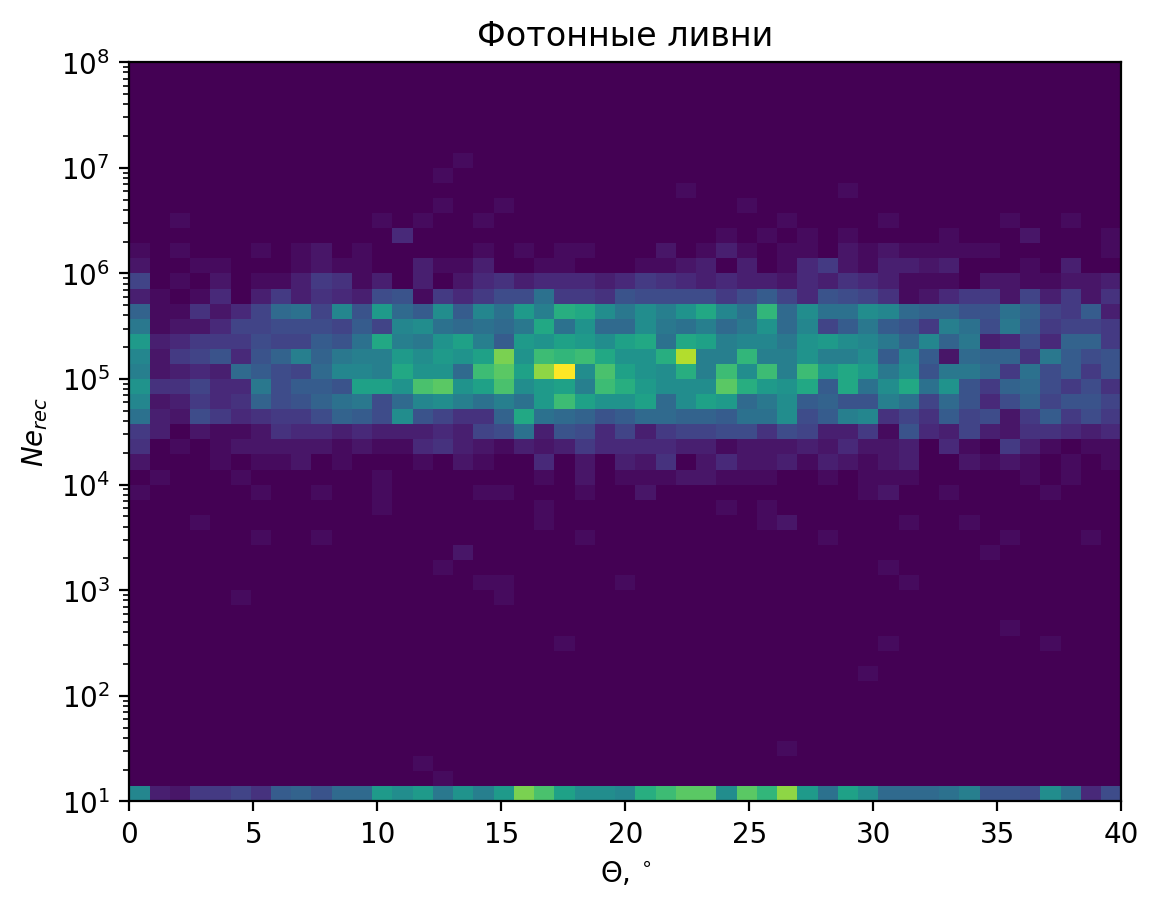

In [39]:
xbins = np.linspace(0, 40, 50)
ybins = 10**np.linspace(1, 8, 50)

plt.hist2d(ReconstructionData['theta_rec'], ReconstructionData['Ne_rec'], bins=(xbins, ybins))

plt.yscale('log')

plt.xlabel('$\Theta, ^\circ$')
plt.ylabel('$Ne_{rec}$')

plt.title('Фотонные ливни')

Text(0.5, 1.0, 'Фотонные ливни')

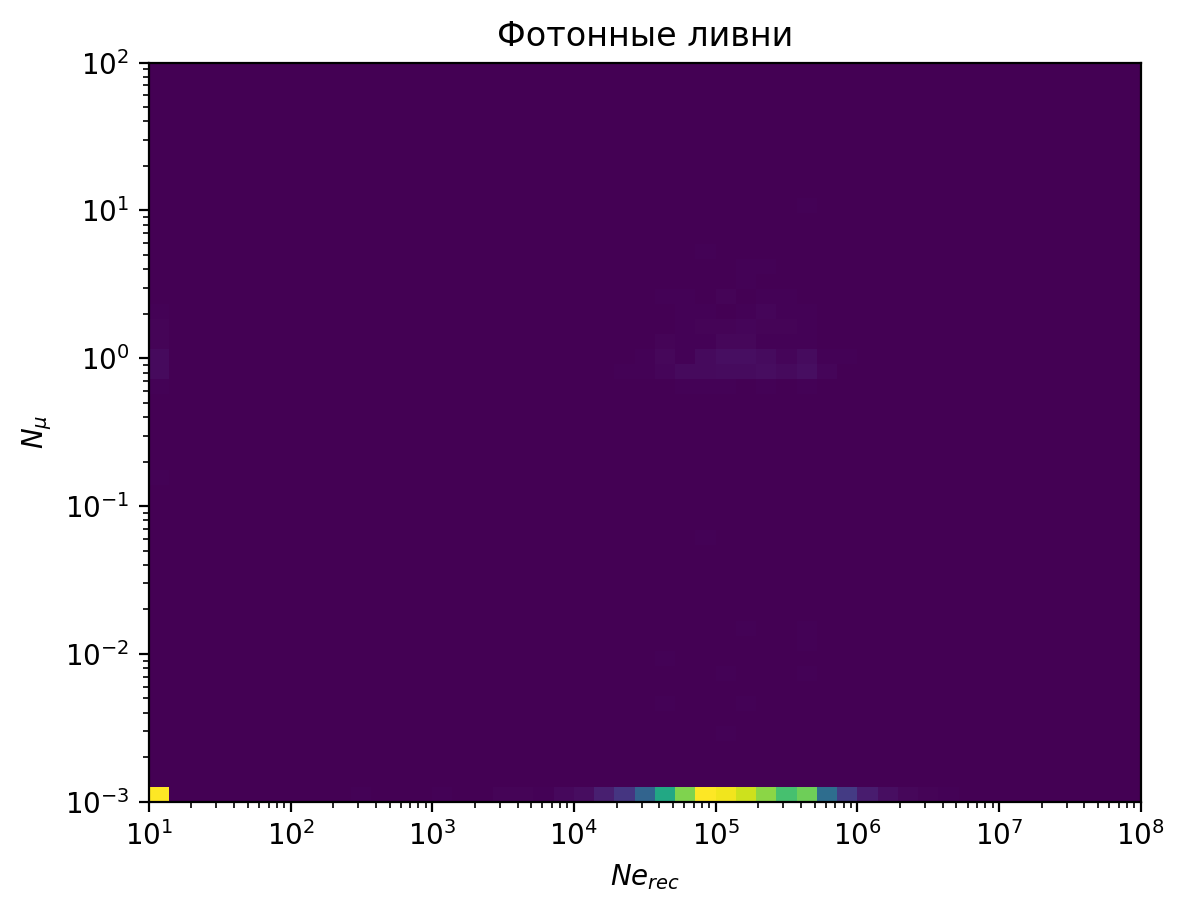

In [28]:
xbins = 10**np.linspace(1, 8, 50)
ybins = 10**np.linspace(-3, 2, 50)

plt.hist2d(ReconstructionData['Ne_rec'], ReconstructionData['N_mu']+0.001, bins=(xbins, ybins))

plt.yscale('log')
plt.xscale('log')

plt.ylabel('$N_\mu$')
plt.xlabel('$Ne_{rec}$')

plt.title('Фотонные ливни')

Text(0.5, 0, '$\\Theta_{true}, ^\\circ$')

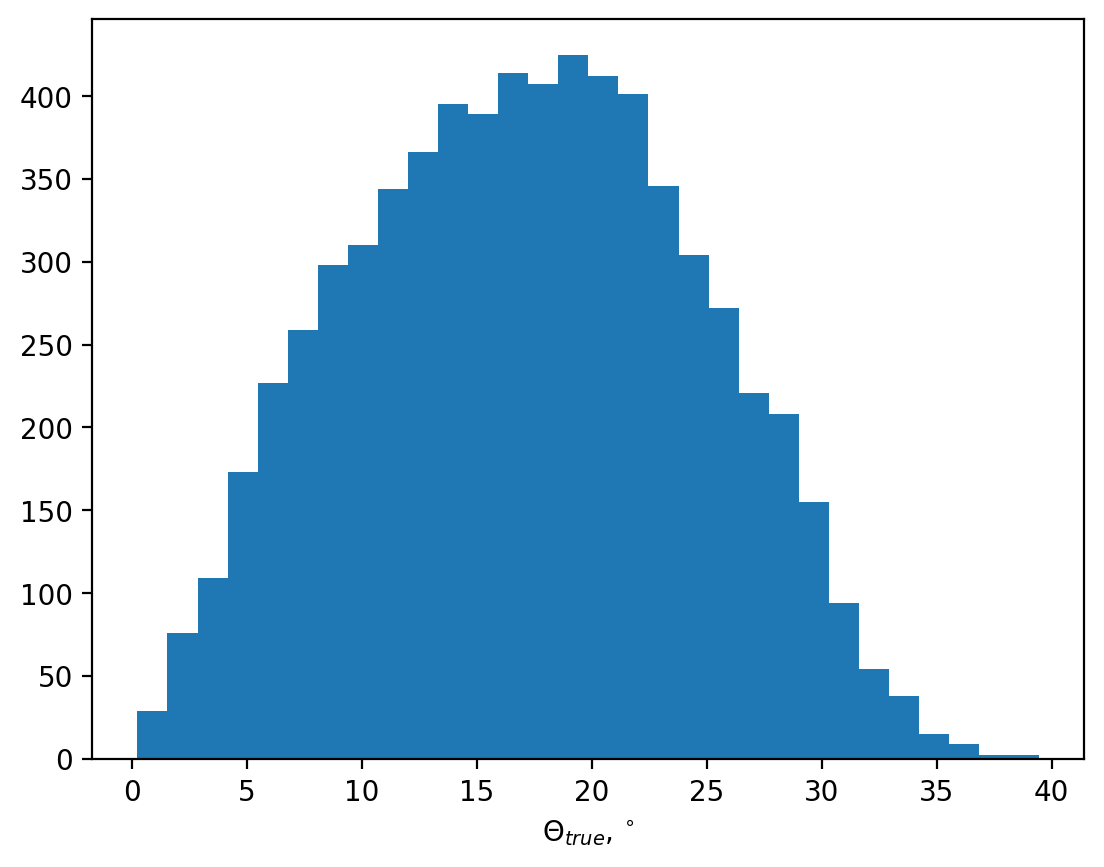

In [16]:
plt.hist(theta_true_arr, bins=30)

plt.xlabel('$\Theta_{true}, ^\circ$')

Text(0.5, 0, '$\\cos\\Theta_{true}, ^\\circ$')

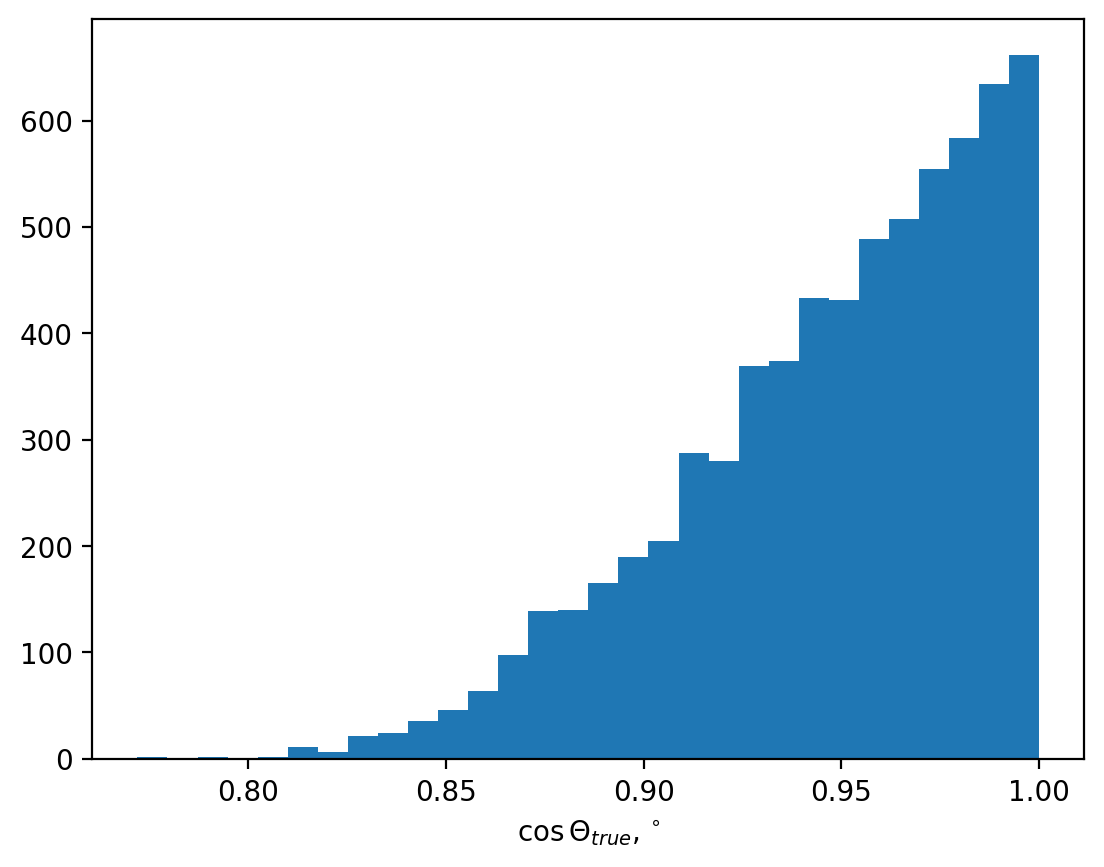

In [22]:
plt.hist(np.cos(np.radians(theta_true_arr)), bins=30)

plt.xlabel('$\cos\Theta_{true}, ^\circ$')

Text(0.5, 0, '$\\Theta_{rec}, ^\\circ$')

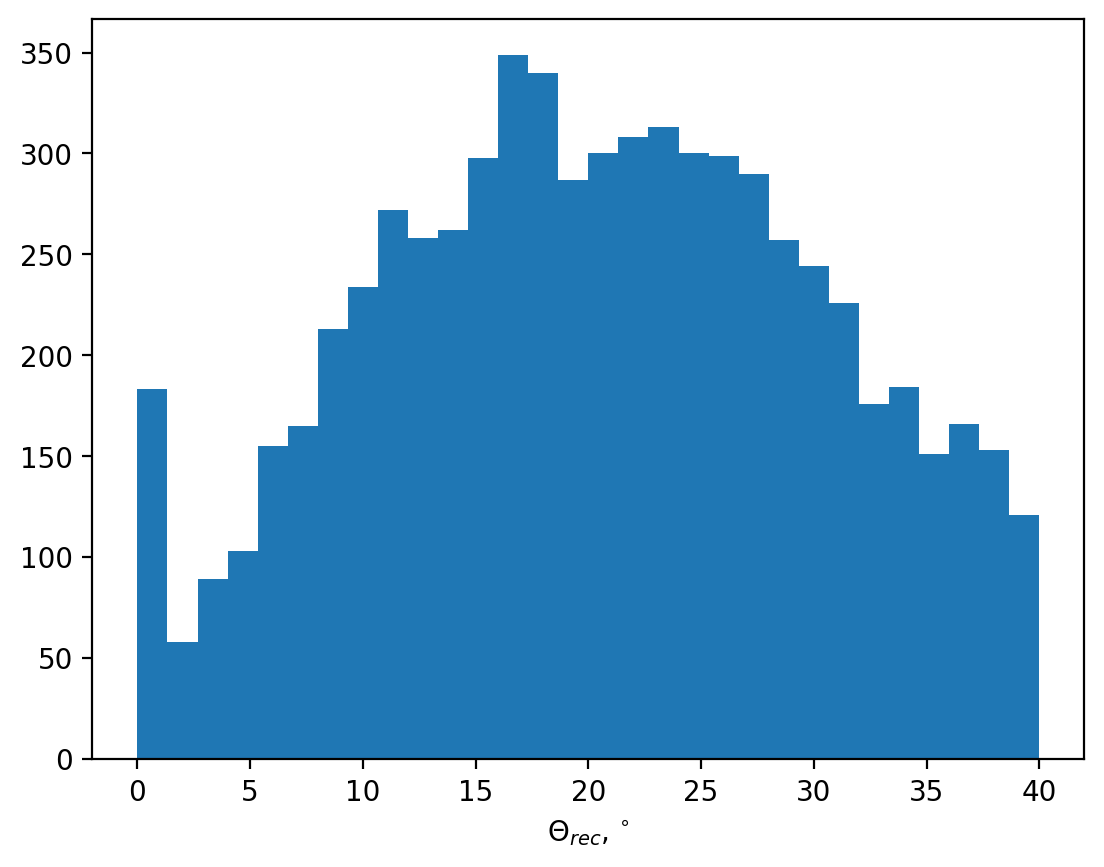

In [17]:
plt.hist(theta_rec_arr, bins=30)

plt.xlabel('$\Theta_{rec}, ^\circ$')

Text(0.5, 0, '$\\cos\\Theta_{rec}, ^\\circ$')

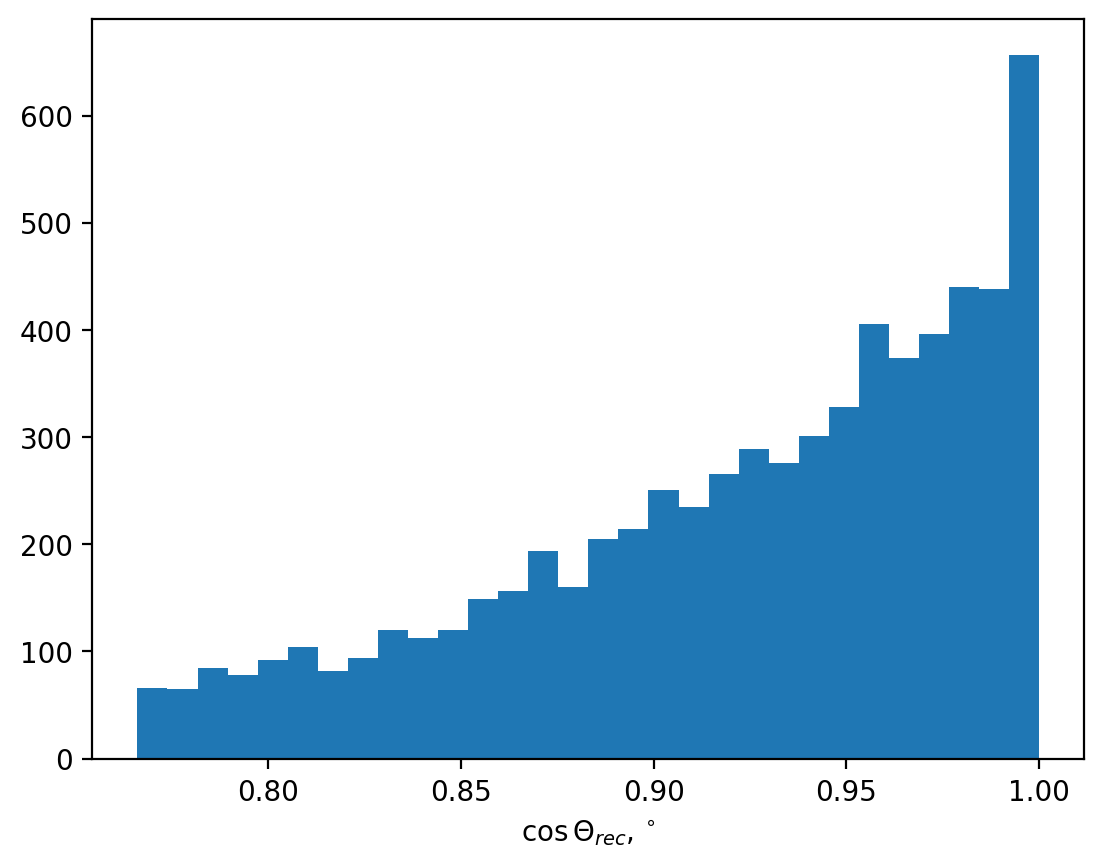

In [19]:
plt.hist(np.cos(np.radians(theta_rec_arr)), bins=30)

plt.xlabel('$\cos\Theta_{rec}, ^\circ$')

(array([212., 218., 249., 228., 227., 192., 211., 178., 185., 210., 250.,
        234., 243., 229., 209., 216., 212., 247., 254., 215., 252., 249.,
        231., 197., 232., 243., 241., 230., 224., 236.]),
 array([-1.79915000e+02, -1.67921433e+02, -1.55927867e+02, -1.43934300e+02,
        -1.31940733e+02, -1.19947167e+02, -1.07953600e+02, -9.59600333e+01,
        -8.39664667e+01, -7.19729000e+01, -5.99793333e+01, -4.79857667e+01,
        -3.59922000e+01, -2.39986333e+01, -1.20050667e+01, -1.15000000e-02,
         1.19820667e+01,  2.39756333e+01,  3.59692000e+01,  4.79627667e+01,
         5.99563333e+01,  7.19499000e+01,  8.39434667e+01,  9.59370333e+01,
         1.07930600e+02,  1.19924167e+02,  1.31917733e+02,  1.43911300e+02,
         1.55904867e+02,  1.67898433e+02,  1.79892000e+02]),
 <BarContainer object of 30 artists>)

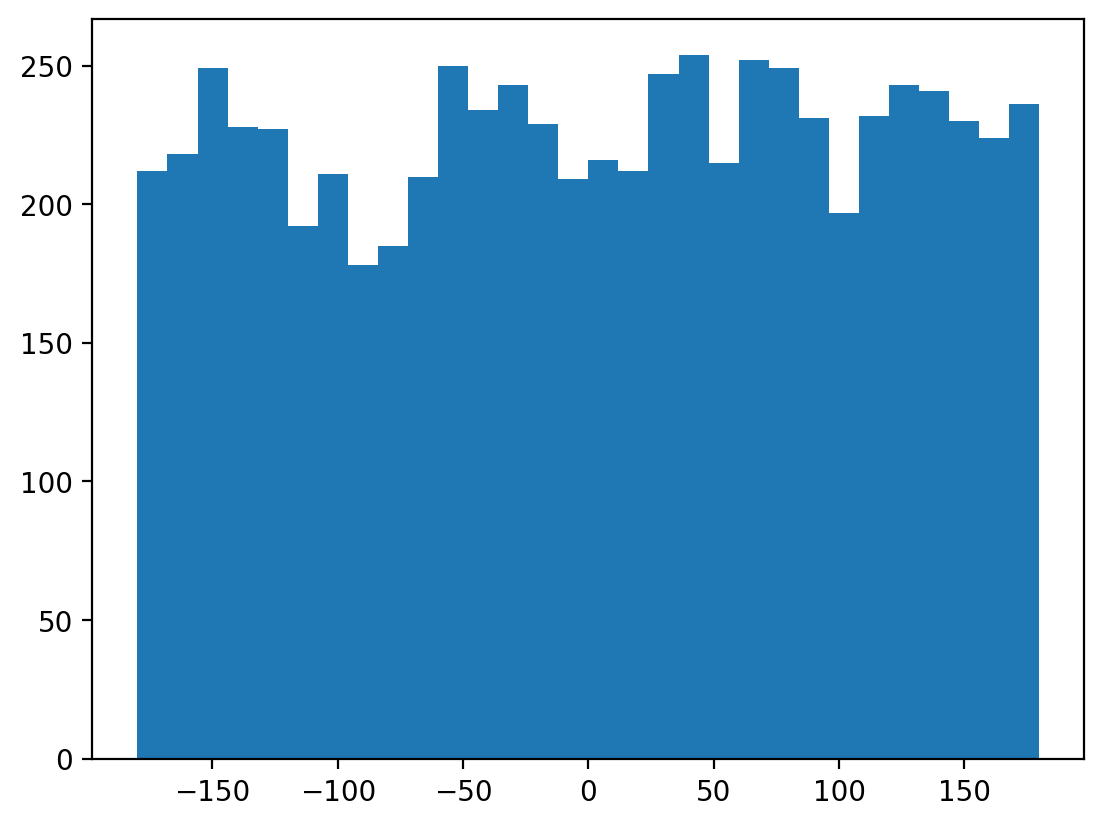

In [29]:
plt.hist(phi_true_arr, bins=30)

(array([239., 214., 198., 239., 230., 232., 223., 217., 230., 226., 251.,
        229., 240., 240., 220., 221., 250., 240., 238., 235., 215., 212.,
        219., 187., 200., 206., 225., 233., 230., 215.]),
 array([3.01938767e-02, 1.20258550e+01, 2.40215161e+01, 3.60171772e+01,
        4.80128383e+01, 6.00084994e+01, 7.20041605e+01, 8.39998216e+01,
        9.59954827e+01, 1.07991144e+02, 1.19986805e+02, 1.31982466e+02,
        1.43978127e+02, 1.55973788e+02, 1.67969449e+02, 1.79965110e+02,
        1.91960771e+02, 2.03956433e+02, 2.15952094e+02, 2.27947755e+02,
        2.39943416e+02, 2.51939077e+02, 2.63934738e+02, 2.75930399e+02,
        2.87926060e+02, 2.99921721e+02, 3.11917382e+02, 3.23913044e+02,
        3.35908705e+02, 3.47904366e+02, 3.59900027e+02]),
 <BarContainer object of 30 artists>)

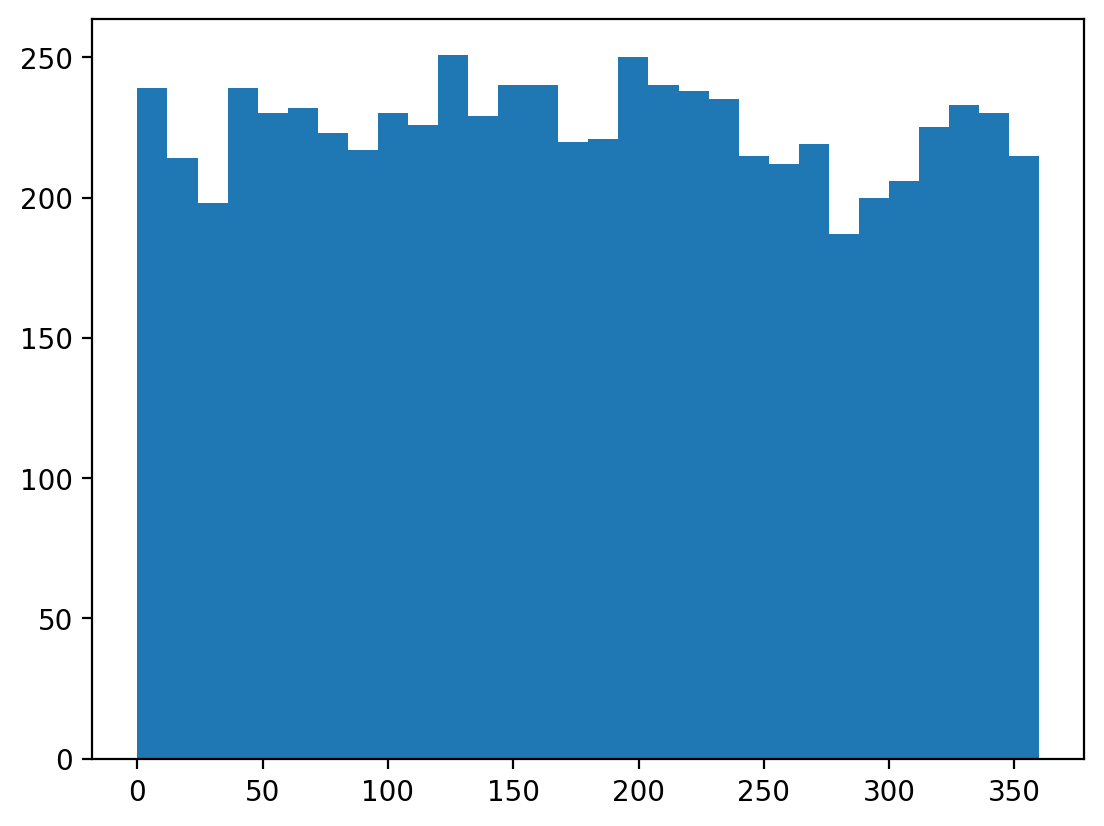

In [30]:
plt.hist(phi_rec_arr, bins=30)